In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma, weibull_min, uniform

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
print(colors)
# blue, orange, green, red, purple, brown, pink, grey, olive, cyan

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


# Probability density function

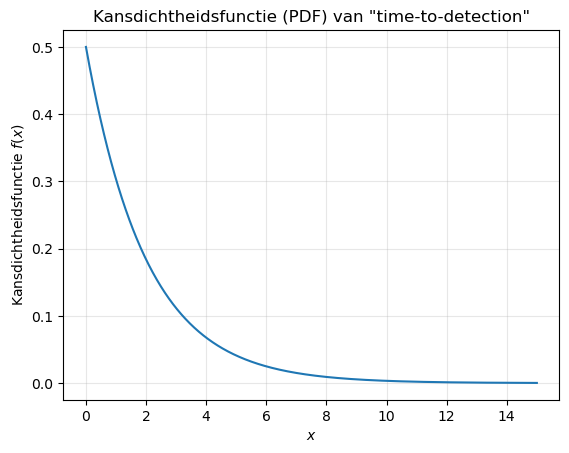

In [87]:
fig, ax = plt.subplots()

# x-axis
x = np.linspace(0, 15, 1_000)
y = 0.5 * np.exp(-0.5 * x)

# Different shape parameters (k)
# shape_params = [2.1]

# for k in shape_params:
#     y = weibull_min.pdf(x, c=k, scale=4)
ax.plot(x, y, color=colors[0])

ax.set_xlabel("$x$")
ax.set_ylabel("Kansdichtheidsfunctie $f(x)$")
ax.set_title('Kansdichtheidsfunctie (PDF) van "time-to-detection"')
ax.grid(True, alpha=0.3)
plt.savefig("./Figures/3_example_pdf.png")

# Hoe bereken je kansen voor continue kansvariabelen?

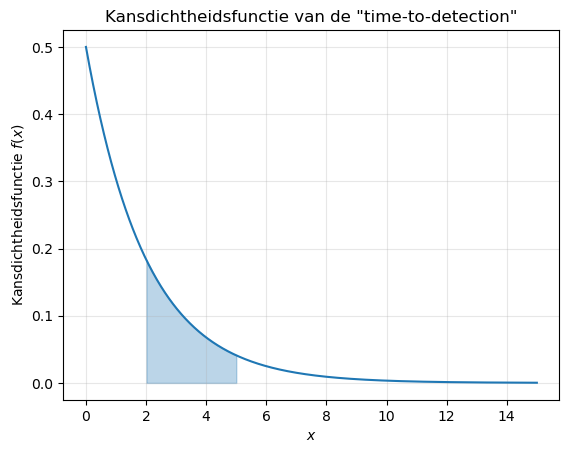

In [89]:
fig, ax = plt.subplots()

# x-axis
x = np.linspace(0, 15, 1_000)
# y = weibull_min.pdf(x, c=2.1, scale=4)
y = 0.5 * np.exp(-0.5 * x)

ax.plot(x, y, color=colors[0])
ax.fill_between(x, y, where=((x>=2)&(x<=5)), ec=colors[0], color=colors[0], alpha=0.3)

ax.set_xlabel("$x$")
ax.set_ylabel("Kansdichtheidsfunctie $f(x)$")
ax.set_title('Kansdichtheidsfunctie van de "time-to-detection"')
ax.grid(True, alpha=0.3)
plt.savefig("./Figures/3_cont_prob.png")

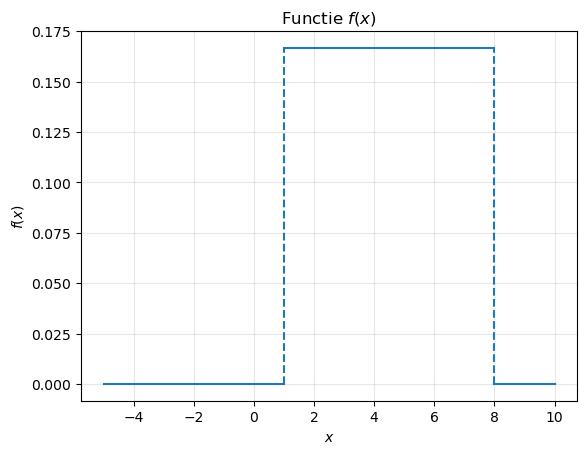

In [11]:
fig, ax = plt.subplots()

# x-axis
x = np.linspace(-5, 10, 1_000)

# Plot of function f(x) = 1/6 for 0 <= x <= 5, and 0 otherwise. This is NOT a pdf!
ax.plot([-5, 1], [0, 0], color=colors[0])
ax.plot([1, 8], [1/6, 1/6], color=colors[0])
ax.plot([8, 10], [0, 0], color=colors[0])

ax.plot([1, 1], [0, 1/6], color=colors[0], linestyle="dashed")
ax.plot([8, 8], [0, 1/6], color=colors[0], linestyle="dashed")

ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title('Functie $f(x)$')
ax.grid(True, alpha=0.3)

plt.savefig("./Figures/3_example_not_pdf.png")

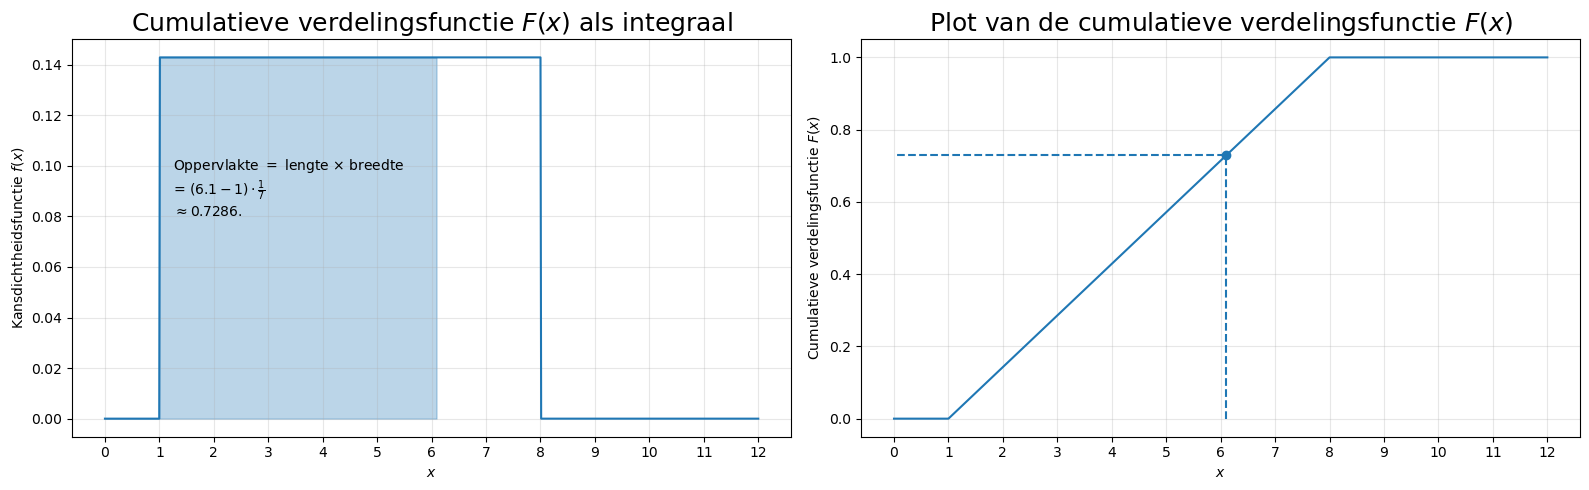

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

TARGET = 6.1

# x-axis
x = np.linspace(0, 12, 1_000)

mask = ((x>1)&(x<8))
y_pdf = uniform.pdf(x, loc=1, scale=7)
# y_pdf = weibull_min.pdf(x, c=2.1, scale=4)
axes[0].plot(x, y_pdf, color=colors[0])
axes[0].fill_between(x, y_pdf, where=((x>=0)&(x<=6.1)), ec=colors[0], color=colors[0], alpha=0.3)

axes[0].annotate("Oppervlakte $=$ lengte $\\times$ breedte \n= $(6.1 - 1) \\cdot \\frac{1}{7}$ \n$\\approx 0.7286$.", xy=(3.5, 0.08), xytext=(1.25, 0.08),
arrowprops=None)


axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Kansdichtheidsfunctie $f(x)$")
axes[0].set_title('Cumulatieve verdelingsfunctie $F(x)$ als integraal', fontsize=18)
axes[0].set_xticks(np.arange(0, 13, 1))
axes[0].grid(True, alpha=0.3)


y_cdf = uniform.cdf(x, loc=1, scale=7) 
# y_cdf = weibull_min.cdf(x, c=2.1, scale=4)
axes[1].plot(x, y_cdf, color=colors[0])

axes[1].scatter([TARGET], [uniform.cdf(TARGET, loc=1, scale=7)])
axes[1].plot([TARGET, TARGET, 0], [0, uniform.cdf(TARGET, loc=1, scale=7), uniform.cdf(TARGET, loc=1, scale=7)], linestyle="dashed")


axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Cumulatieve verdelingsfunctie $F(x)$")
axes[1].set_title('Plot van de cumulatieve verdelingsfunctie $F(x)$', fontsize=18)
axes[1].set_xticks(np.arange(0, 13, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./Figures/3_cumulative_distribution_function.png")

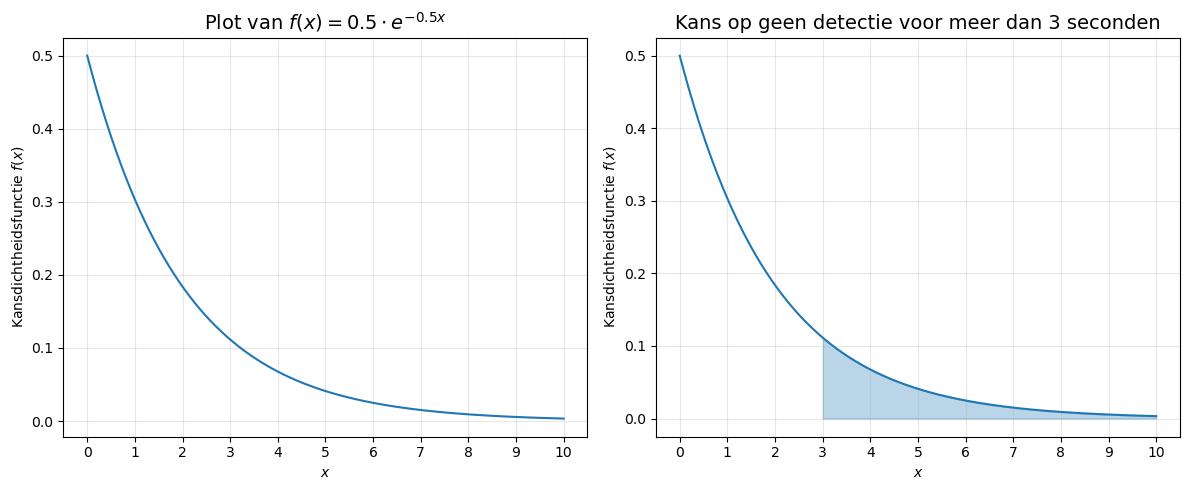

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# x-axis
x = np.linspace(0, 10, 1_000)
# y = 0.003 * (10 - x) ** 2
y = 0.5 * np.exp(-0.5 * x)

axes[0].plot(x, y, color=colors[0])
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("Kansdichtheidsfunctie $f(x)$")
# axes[0].set_title('Plot van $f(x) = 0.003 \\cdot (10 - x)^2$', fontsize=14)
axes[0].set_title('Plot van $f(x) = 0.5 \\cdot e^{-0.5x}$', fontsize=14)
axes[0].set_xticks(np.arange(0, 11, 1))
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, y, color=colors[0])
axes[1].fill_between(x, y, where=((x>=3)&(x<=10)), ec=colors[0], alpha=0.3)
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("Kansdichtheidsfunctie $f(x)$")
axes[1].set_title('Kans op geen detectie voor meer dan 3 seconden', fontsize=14)
axes[1].set_xticks(np.arange(0, 11, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("./Figures/3_example_exercise.png")